# Heston FNO — Results, Evaluation & Pricing Surfaces

This notebook evaluates the trained Heston Fourier Neural Operator (FNO) checkpoint and
creates the figures needed for the project report.

It produces:

- training/validation loss curve
- RMSE, MAE, maximum absolute error, mean relative error, relative L2 error and R²
- predicted vs. ground-truth pricing surfaces
- absolute-error surface
- predicted-vs-true scatter plot
- absolute-error histogram
- a pricing cross-section at a selected variance value
- Delta-like sensitivity and a Vega-like (v0-sensitivity) surface
- FNO inference-time benchmark
- optional ADI benchmark cell (disabled by default)

The notebook does **not** retrain the model.

## 1. Colab setup — use the same paths as `colab_train(1).ipynb`

This notebook intentionally uses the exact Colab repository location and Drive/data layout from your training notebook.

In [11]:
# ============================================================
# STEP 1 — Clone repo + install project
# Same setup as colab_train(1).ipynb
# ============================================================

import os
import sys
import math
import shutil
from pathlib import Path

REPO = Path("/content/FNO-for-Heston-Pricing-Engine-")
ROOT = REPO

if not REPO.exists():
    !git clone https://github.com/bananapants-87/FNO-for-Heston-Pricing-Engine-.git

os.chdir(REPO)

# Same install approach as the training notebook.
!pip install -q neuraloperator pyyaml
!pip install -q -e . --no-deps

print("Working directory:", os.getcwd())
print("Repository exists:", REPO.exists())

# ============================================================
# STEP 2 — Mount Drive and copy the same four data files
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = REPO / "data" / "final"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Shared evaluation settings used by later cells.
RESULTS_DIR = REPO / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EVAL_MAX_SAMPLES = None  # Set an integer for a faster smoke test.
SURFACE_TEST_POSITION = 0
FNO_BENCHMARK_BATCH_SIZE = 4
FNO_WARMUP = 5
FNO_REPEATS = 20
RUN_ADI_BENCHMARK = False
ADI_STRIKE = 100.0
ADI_RATE = 0.05
ADI_MATURITY = 1.0
ADI_N_STEPS = 100
ADI_WARMUP = 1
ADI_REPEATS = 3

files = ["inputs.pt", "targets.pt", "s_grid.pt", "v_grid.pt"]

candidates = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/MyDrive/final"),
    Path("/content/final"),
    Path("/content"),
]

for fname in files:
    destination = DATA_DIR / fname

    if destination.exists():
        print(fname, "already present")
        continue

    found = False
    for location in candidates:
        source = location / fname
        if source.exists():
            shutil.copy2(source, destination)
            print("Copied:", fname, "from", source)
            found = True
            break

    if not found:
        print("MISSING:", fname)

print("\n--- DATA VERIFICATION ---")
for fname in files:
    p = DATA_DIR / fname
    print(f"{fname:12} ->", "FOUND" if p.exists() else "MISSING")

# ============================================================
# FIND / RESTORE THE TRAINED CHECKPOINT
# ============================================================

from pathlib import Path
import shutil

REPO = Path("/content/FNO-for-Heston-Pricing-Engine-")
CHECKPOINT_PATH = REPO / "checkpoints" / "heston_fno.pth"

# Possible locations for the trained checkpoint
checkpoint_candidates = [
    CHECKPOINT_PATH,
    Path("/content/heston_fno.pth"),
    Path("/content/drive/MyDrive/heston_fno.pth"),
    Path("/content/drive/MyDrive/checkpoints/heston_fno.pth"),
    Path("/content/drive/MyDrive/FNO-for-Heston-Pricing-Engine-/checkpoints/heston_fno.pth"),
]

# Make sure the destination folder exists
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Find the first existing checkpoint
found_checkpoint = None

for candidate in checkpoint_candidates:
    if candidate.exists():
        found_checkpoint = candidate
        break

if found_checkpoint is None:
    raise FileNotFoundError(
        "No heston_fno.pth was found.\n\n"
        "Your training must finish first and create:\n"
        "/content/FNO-for-Heston-Pricing-Engine-/checkpoints/heston_fno.pth\n\n"
        "Or save the checkpoint to Google Drive, for example:\n"
        "/content/drive/MyDrive/heston_fno.pth"
    )

# Copy it into the location expected by results.ipynb
if found_checkpoint != CHECKPOINT_PATH:
    shutil.copy2(found_checkpoint, CHECKPOINT_PATH)
    print("Checkpoint copied from:")
    print(found_checkpoint)
    print("\nTo:")
    print(CHECKPOINT_PATH)
else:
    print("Checkpoint already exists at:")
    print(CHECKPOINT_PATH)

print("\nCheckpoint size:",
      round(CHECKPOINT_PATH.stat().st_size / (1024**2), 2),
      "MB")

print("READY — you can now run the next results notebook cell.")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for heston-fno (pyproject.toml) ... done
Working directory: /content/FNO-for-Heston-Pricing-Engine-
Repository exists: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
inputs.pt already present
targets.pt already present
s_grid.pt already present
v_grid.pt already present

--- DATA VERIFICATION ---
inputs.pt    -> FOUND
targets.pt   -> FOUND
s_grid.pt    -> FOUND
v_grid.pt    -> FOUND
Checkpoint copied from:
/content/drive/MyDrive/heston_fno.pth

To:
/content/FNO-for-Heston-Pricing-Engine-/checkpoints/heston_fno.pth

Checkpoint size: 3.95 MB
READY — you can now run the next results notebook cell.


In [13]:
# ============================================================
# SETUP PATHS BEFORE IMPORTING heston_fno
# ============================================================

from pathlib import Path
import sys
import os
import subprocess

REPO = Path("/content/FNO-for-Heston-Pricing-Engine-")

# Make sure the repo exists
if not REPO.exists():
    !git clone https://github.com/bananapants-87/FNO-for-Heston-Pricing-Engine-.git

# Move into the project directory
os.chdir(REPO)

# Add src/ so "from heston_fno ..." works
SRC = REPO / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Working directory:", Path.cwd())
print("SRC path:", SRC)
print("src exists:", SRC.exists())

# Install project dependencies
!pip install -q neuraloperator pyyaml
!pip install -q -e . --no-deps

# ============================================================
# NOW import your project modules
# ============================================================

import torch
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from heston_fno.data.dataset import HestonDataset
from heston_fno.data.preprocessing import split_indices
from heston_fno.data.normalization import StandardScaler
from heston_fno.models.fno import build_model_from_config
from heston_fno.evaluation.errors import summarize_errors
from heston_fno.evaluation.greeks import (
    compute_delta,
    compute_vega,
    compute_reference_delta,
    compare_greeks,
)
from heston_fno.benchmarking.fno import benchmark_fno

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Working directory: /content/FNO-for-Heston-Pricing-Engine-
SRC path: /content/FNO-for-Heston-Pricing-Engine-/src
src exists: True


  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for heston-fno (pyproject.toml) ... done
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Load the trained checkpoint, saved configuration and scalers

The checkpoint is the file produced by `scripts/train_fno.py` at:

`/content/FNO-for-Heston-Pricing-Engine-/checkpoints/heston_fno.pth`

The training script stores the model state, configuration, training history, input scaler and target scaler in this file.

In [14]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

saved_config = checkpoint.get("config", None)
if saved_config is None:
    with open(ROOT / "configs" / "fno.yaml", "r", encoding="utf-8") as f:
        saved_config = yaml.safe_load(f) or {}

model = build_model_from_config(saved_config).to(device)

state_dict = checkpoint["model_state_dict"]
state_dict = {k: v for k, v in state_dict.items() if k != "_metadata"}
model.load_state_dict(state_dict)
model.eval()

input_scaler = StandardScaler()
target_scaler = StandardScaler()

if "input_scaler" in checkpoint and "target_scaler" in checkpoint:
    input_scaler.load_state_dict(checkpoint["input_scaler"])
    target_scaler.load_state_dict(checkpoint["target_scaler"])
else:
    raise KeyError(
        "Checkpoint does not contain input_scaler/target_scaler. "
        "Use a checkpoint created by the current train_fno.py."
    )

history = checkpoint.get("history", {})

print("Checkpoint loaded successfully.")
print("Saved epoch:", checkpoint.get("epoch", "not stored"))
print("Best validation loss:", checkpoint.get("best_val_loss", "not stored"))
print("Saved model config:", saved_config.get("model", {}))
print("History keys:", list(history.keys()))

Checkpoint loaded successfully.
Saved epoch: 1
Best validation loss: 0.23854212743043898
Saved model config: {'n_modes': [8, 8], 'hidden_channels': 32, 'in_channels': 7, 'out_channels': 1}
History keys: ['train_loss', 'val_loss']


## 3. Load the complete dataset and recreate the exact deterministic split

The repo uses an 80/10/10 split with seed `42` in the current configuration.

We use the raw dataset here, then apply the scaler stored in the trained checkpoint.
This avoids accidentally fitting new normalization statistics during evaluation.

In [15]:
full_dataset = HestonDataset(
    inputs_path=DATA_DIR / "inputs.pt",
    targets_path=DATA_DIR / "targets.pt",
    s_grid_path=DATA_DIR / "s_grid.pt",
    v_grid_path=DATA_DIR / "v_grid.pt",
)

split_cfg = saved_config.get("training", {}).get("split", [0.8, 0.1, 0.1])
seed = saved_config.get("training", {}).get("seed", 42)

train_idx, val_idx, test_idx = split_indices(
    len(full_dataset),
    split=split_cfg,
    seed=seed,
)

print("Total samples:", len(full_dataset))
print("Train samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))
print("Input sample shape:", tuple(full_dataset[0][0].shape))
print("Target sample shape:", tuple(full_dataset[0][1].shape))
print("S grid shape:", tuple(full_dataset.s_grid.shape))
print("v grid shape:", tuple(full_dataset.v_grid.shape))

Total samples: 50000
Train samples: 40000
Validation samples: 5000
Test samples: 5000
Input sample shape: (7, 64, 32)
Target sample shape: (1, 64, 32)
S grid shape: (64,)
v grid shape: (32,)


In [16]:
class ScaledIndexDataset(Dataset):
    def __init__(self, base_dataset, indices, input_scaler, target_scaler):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.input_scaler = input_scaler
        self.target_scaler = target_scaler

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x_raw, y_raw = self.base_dataset[idx]
        x = self.input_scaler.transform(x_raw)
        y = self.target_scaler.transform(y_raw)
        return x, y

test_indices_used = list(test_idx)
if EVAL_MAX_SAMPLES is not None:
    test_indices_used = test_indices_used[: int(EVAL_MAX_SAMPLES)]

test_scaled_dataset = ScaledIndexDataset(
    full_dataset,
    test_indices_used,
    input_scaler,
    target_scaler,
)

eval_batch_size = int(
    saved_config.get("training", {}).get("batch_size", 4)
)

test_loader = DataLoader(
    test_scaled_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    num_workers=0,
)

print("Samples used for evaluation:", len(test_scaled_dataset))
print("Evaluation batch size:", eval_batch_size)

Samples used for evaluation: 5000
Evaluation batch size: 4


## 4. Evaluate the held-out test set

These metrics are computed in **physical option-price units** after inverse normalization.

The per-point mean relative error is retained for consistency with `scripts/evaluate.py`,
but it can become very large near target prices close to zero. The relative L2 error is
also reported because it is less sensitive to individual near-zero grid points.

In [17]:
model.eval()

sum_sq = 0.0
sum_abs = 0.0
sum_rel = 0.0
sum_y = 0.0
sum_y2 = 0.0
sum_count = 0
max_abs = 0.0

with torch.no_grad():
    for x_scaled, y_scaled in test_loader:
        x_scaled = x_scaled.to(device)
        y_scaled = y_scaled.to(device)

        pred_scaled = model(x_scaled)

        pred = target_scaler.inverse_transform(pred_scaled)
        y = target_scaler.inverse_transform(y_scaled)

        diff = pred - y
        abs_diff = torch.abs(diff)

        sum_sq += torch.sum(diff ** 2).item()
        sum_abs += torch.sum(abs_diff).item()
        sum_rel += torch.sum(abs_diff / (torch.abs(y) + 1e-6)).item()

        sum_y += torch.sum(y).item()
        sum_y2 += torch.sum(y ** 2).item()
        sum_count += y.numel()

        batch_max = abs_diff.max().item()
        max_abs = max(max_abs, batch_max)

rmse_value = math.sqrt(sum_sq / max(sum_count, 1))
mae_value = sum_abs / max(sum_count, 1)
mre_value = sum_rel / max(sum_count, 1)

relative_l2_value = math.sqrt(sum_sq) / (math.sqrt(sum_y2) + 1e-7)

# Global R² over all price-grid points.
mean_y = sum_y / max(sum_count, 1)
sst = sum_y2 - 2.0 * mean_y * sum_y + sum_count * (mean_y ** 2)
r2_value = 1.0 - (sum_sq / sst) if sst > 0 else float("nan")

metrics = {
    "RMSE": rmse_value,
    "MAE": mae_value,
    "Maximum Absolute Error": max_abs,
    "Mean Relative Error": mre_value,
    "Relative L2 Error": relative_l2_value,
    "R2": r2_value,
}

metrics_df = pd.DataFrame(
    [{"Metric": k, "Value": v} for k, v in metrics.items()]
)

display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "evaluation_metrics.csv", index=False)

print("\nMetrics saved to:", RESULTS_DIR / "evaluation_metrics.csv")

,Metric,Value
0,RMSE,2.510954e+01
1,MAE,1.932527e+01
2,Maximum Absolute Error,1.201769e+02
3,Mean Relative Error,1.424089e+06
4,Relative L2 Error,3.697271e-01
5,R2,7.616898e-01



Metrics saved to: /content/FNO-for-Heston-Pricing-Engine-/results/evaluation_metrics.csv


## 5. Training and validation loss curve

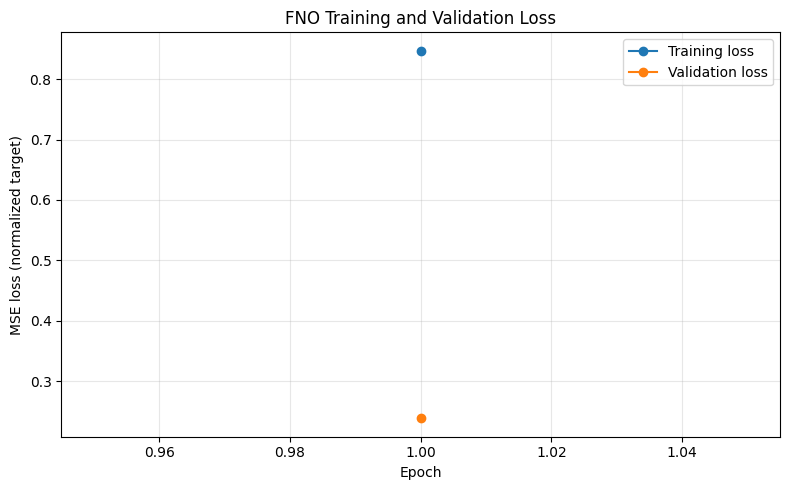

In [18]:
train_loss = history.get("train_loss", [])
val_loss = history.get("val_loss", [])

if len(train_loss) == 0:
    print("No training history found in the checkpoint.")
else:
    epochs = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, marker="o", label="Training loss")
    if len(val_loss) == len(train_loss):
        plt.plot(epochs, val_loss, marker="o", label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("MSE loss (normalized target)")
    plt.title("FNO Training and Validation Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "training_validation_loss.png", dpi=200)
    plt.show()

## 6. Select one held-out test sample and predict its full pricing surface

In [19]:
if SURFACE_TEST_POSITION < 0 or SURFACE_TEST_POSITION >= len(test_idx):
    raise IndexError(
        f"SURFACE_TEST_POSITION must be between 0 and {len(test_idx)-1}."
    )

surface_raw_index = int(test_idx[SURFACE_TEST_POSITION])

x_raw, y_raw = full_dataset[surface_raw_index]

x_scaled = input_scaler.transform(x_raw).unsqueeze(0)
y_scaled = target_scaler.transform(y_raw).unsqueeze(0)

with torch.no_grad():
    pred_scaled = model(x_scaled.to(device))

pred_surface = target_scaler.inverse_transform(pred_scaled).cpu()[0]
true_surface = y_raw.unsqueeze(0).cpu()[0]

abs_error_surface = torch.abs(pred_surface - true_surface)

s_grid = full_dataset.s_grid.cpu()
v_grid = full_dataset.v_grid.cpu()

S, V = torch.meshgrid(s_grid, v_grid, indexing="ij")
S_np = S.numpy()
V_np = V.numpy()

pred_np = pred_surface.squeeze(0).numpy()
true_np = true_surface.squeeze(0).numpy()
err_np = abs_error_surface.squeeze(0).numpy()

print("Original dataset sample index:", surface_raw_index)
print("Parameter values [kappa, theta, sigma, rho, v0]:")
print(full_dataset.params[surface_raw_index].numpy())
print("Surface shape:", pred_surface.shape)
print("True surface min/max:", true_surface.min().item(), true_surface.max().item())
print("Predicted surface min/max:", pred_surface.min().item(), pred_surface.max().item())

Original dataset sample index: 17408
Parameter values [kappa, theta, sigma, rho, v0]:
[ 1.6308476   0.03988144  0.30609807 -0.58443576  0.04305916]
Surface shape: torch.Size([1, 64, 32])
True surface min/max: 0.0 204.87705993652344
Predicted surface min/max: 10.669097900390625 125.2308120727539


## 7. Ground-truth pricing surface

This is the reference pricing surface stored in `targets.pt`.
In your project these are the prices generated by the reference PDE/ADI workflow used to
construct the dataset.

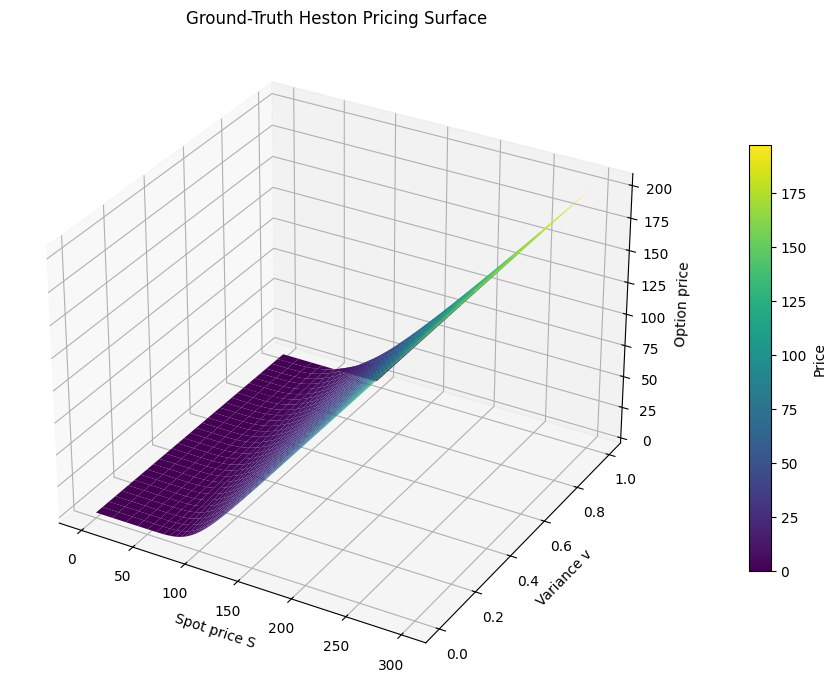

In [20]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_np, V_np, true_np, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("Spot price S")
ax.set_ylabel("Variance v")
ax.set_zlabel("Option price")
ax.set_title("Ground-Truth Heston Pricing Surface")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="Price")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "ground_truth_pricing_surface_3d.png", dpi=200)
plt.show()

## 8. FNO predicted pricing surface

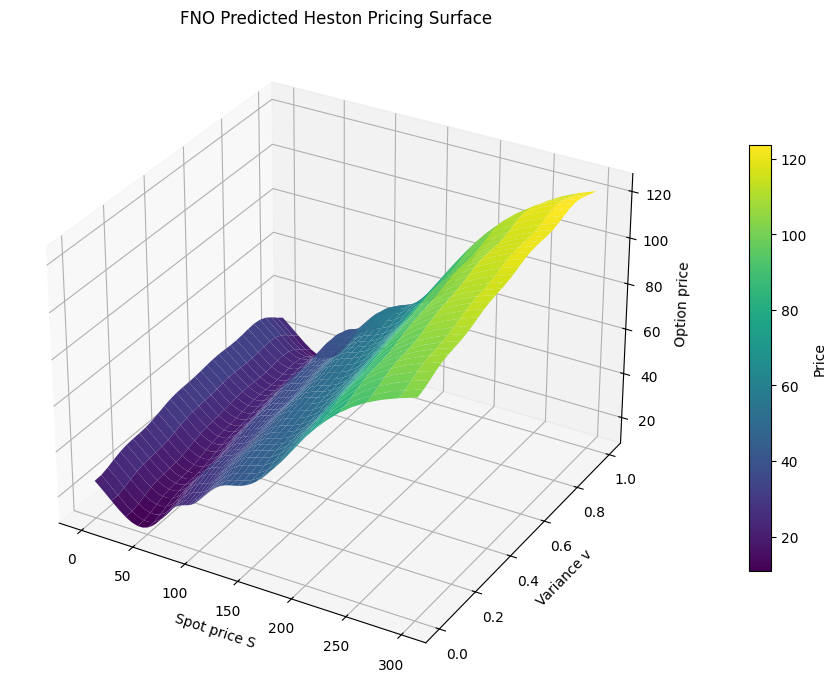

In [21]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_np, V_np, pred_np, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("Spot price S")
ax.set_ylabel("Variance v")
ax.set_zlabel("Option price")
ax.set_title("FNO Predicted Heston Pricing Surface")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="Price")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fno_predicted_pricing_surface_3d.png", dpi=200)
plt.show()

## 9. Absolute-error surface

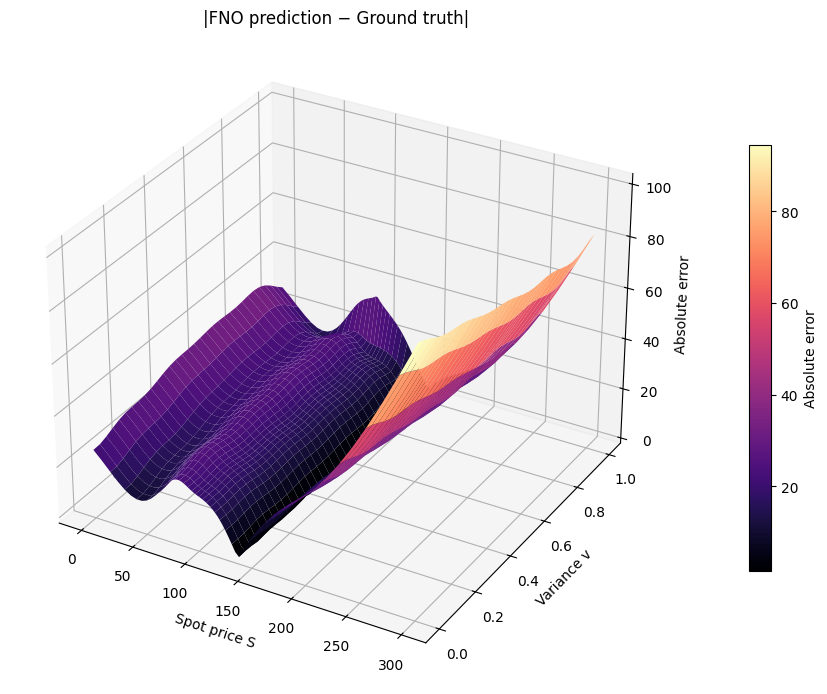

In [22]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_np, V_np, err_np, cmap="magma", linewidth=0, antialiased=True)
ax.set_xlabel("Spot price S")
ax.set_ylabel("Variance v")
ax.set_zlabel("Absolute error")
ax.set_title("|FNO prediction − Ground truth|")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="Absolute error")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "absolute_error_surface_3d.png", dpi=200)
plt.show()

## 10. 2D heatmaps

The 2D views are often easier to put into a report than 3D plots.

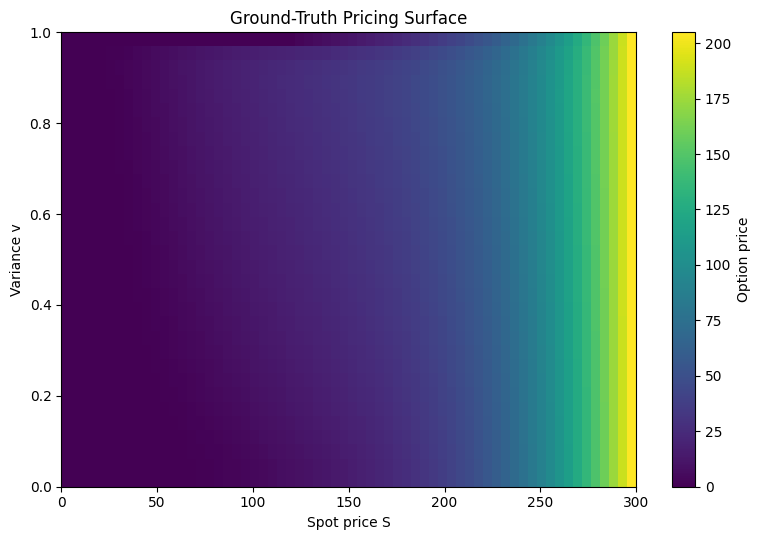

In [23]:
fig = plt.figure(figsize=(8, 5.5))
plt.imshow(
    true_np.T,
    origin="lower",
    aspect="auto",
    extent=[s_grid.min().item(), s_grid.max().item(), v_grid.min().item(), v_grid.max().item()],
)
plt.xlabel("Spot price S")
plt.ylabel("Variance v")
plt.title("Ground-Truth Pricing Surface")
plt.colorbar(label="Option price")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ground_truth_pricing_surface_2d.png", dpi=200)
plt.show()

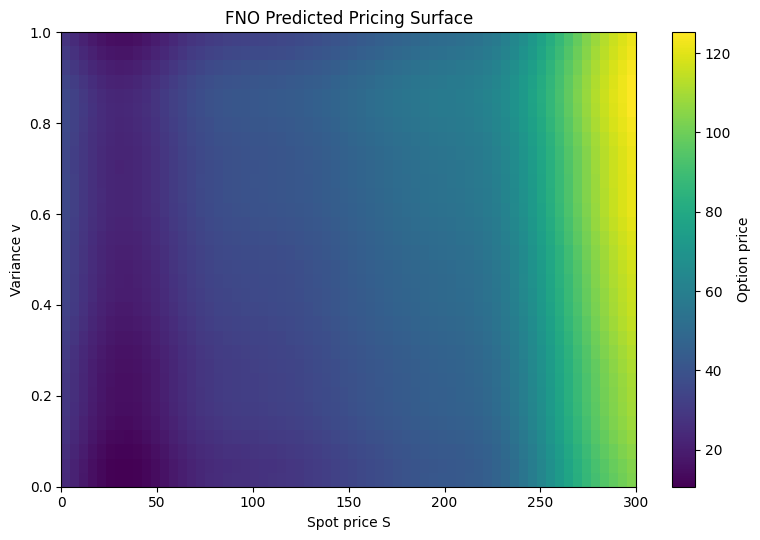

In [24]:
fig = plt.figure(figsize=(8, 5.5))
plt.imshow(
    pred_np.T,
    origin="lower",
    aspect="auto",
    extent=[s_grid.min().item(), s_grid.max().item(), v_grid.min().item(), v_grid.max().item()],
)
plt.xlabel("Spot price S")
plt.ylabel("Variance v")
plt.title("FNO Predicted Pricing Surface")
plt.colorbar(label="Option price")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fno_predicted_pricing_surface_2d.png", dpi=200)
plt.show()

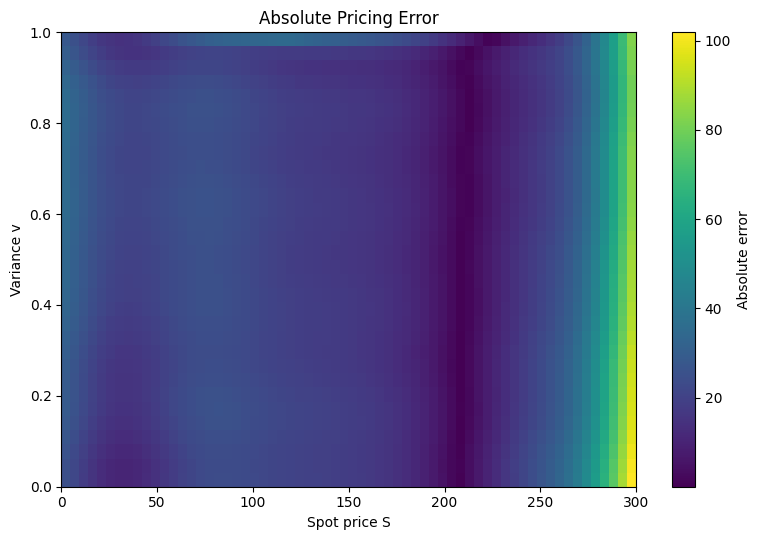

In [25]:
fig = plt.figure(figsize=(8, 5.5))
plt.imshow(
    err_np.T,
    origin="lower",
    aspect="auto",
    extent=[s_grid.min().item(), s_grid.max().item(), v_grid.min().item(), v_grid.max().item()],
)
plt.xlabel("Spot price S")
plt.ylabel("Variance v")
plt.title("Absolute Pricing Error")
plt.colorbar(label="Absolute error")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "absolute_error_surface_2d.png", dpi=200)
plt.show()

## 11. Predicted-vs-true price comparison

This checks how closely individual grid-point predictions follow the reference prices.

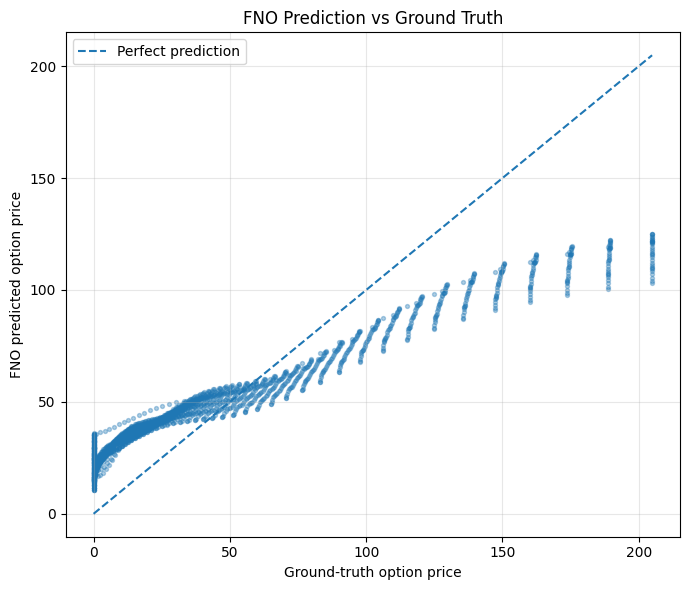

In [26]:
true_flat = true_np.ravel()
pred_flat = pred_np.ravel()

fig = plt.figure(figsize=(7, 6))
plt.scatter(true_flat, pred_flat, s=8, alpha=0.35)

lo = min(true_flat.min(), pred_flat.min())
hi = max(true_flat.max(), pred_flat.max())
plt.plot([lo, hi], [lo, hi], linestyle="--", label="Perfect prediction")

plt.xlabel("Ground-truth option price")
plt.ylabel("FNO predicted option price")
plt.title("FNO Prediction vs Ground Truth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "prediction_vs_ground_truth.png", dpi=200)
plt.show()

## 12. Absolute-error histogram

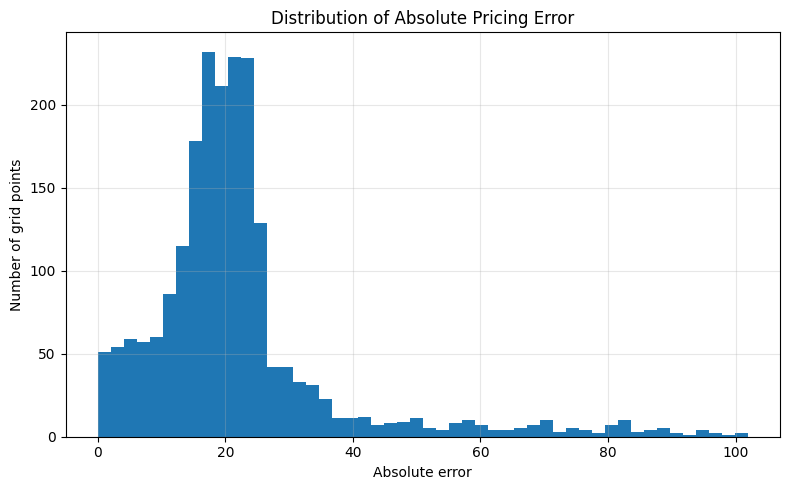

In [27]:
fig = plt.figure(figsize=(8, 5))
plt.hist(np.abs(pred_flat - true_flat), bins=50)
plt.xlabel("Absolute error")
plt.ylabel("Number of grid points")
plt.title("Distribution of Absolute Pricing Error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "absolute_error_histogram.png", dpi=200)
plt.show()

## 13. Pricing cross-section at one variance level

This gives a conventional 2D pricing curve:

`S → option price`

for a fixed variance-grid index.

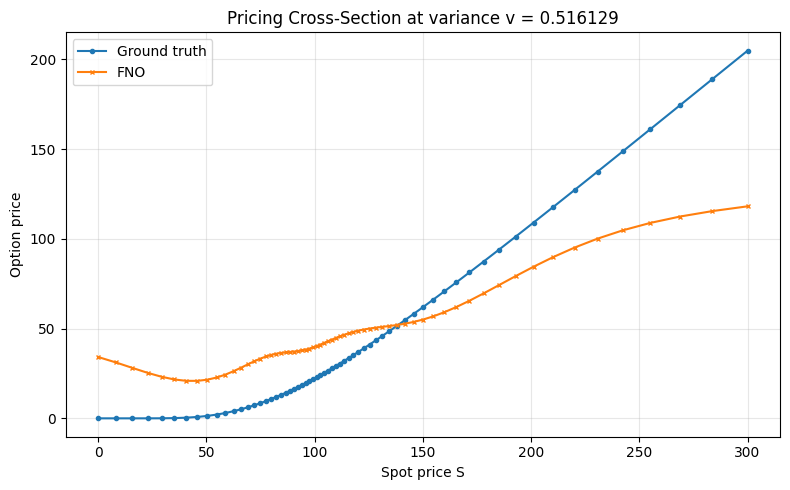

In [28]:
v_index = len(v_grid) // 2
v_value = v_grid[v_index].item()

fig = plt.figure(figsize=(8, 5))
plt.plot(s_grid.numpy(), true_np[:, v_index], marker="o", markersize=3, label="Ground truth")
plt.plot(s_grid.numpy(), pred_np[:, v_index], marker="x", markersize=3, label="FNO")

plt.xlabel("Spot price S")
plt.ylabel("Option price")
plt.title(f"Pricing Cross-Section at variance v = {v_value:.6g}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pricing_cross_section.png", dpi=200)
plt.show()

## 14. Error summary for the selected surface

In [29]:
surface_summary = summarize_errors(
    pred_surface.unsqueeze(0),
    true_surface.unsqueeze(0),
).to_dict()

surface_summary_df = pd.DataFrame(
    [{"Metric": k, "Value": v} for k, v in surface_summary.items()]
)
display(surface_summary_df)
surface_summary_df.to_csv(RESULTS_DIR / "selected_surface_metrics.csv", index=False)

,Metric,Value
0,mean_absolute_error,2.206908e+01
1,mean_relative_error,1.652808e+06
2,rmse,2.688056e+01
3,max_absolute_error,1.018818e+02
4,relative_l2_error,3.938712e-01


## 15. Greeks / sensitivities

The repository provides:

- `compute_delta()` — derivative of the FNO output with respect to the spot-price `S` input channel.
- `compute_vega()` — derivative with respect to the initial variance `v0` input channel, so this is best
  described here as **Vega-like / v0 sensitivity**.

A reference Delta can be obtained directly from the ground-truth pricing surface by numerical differentiation.

The repository's `compute_reference_vega()` differentiates the pricing surface with respect to the
grid coordinate `v`; that is **not the same derivative** as `dV/dv0`, so this notebook does not
present those two quantities as a direct Vega-vs-reference comparison.

In [30]:
# FNO Delta and v0-sensitivity for the selected sample.
delta_surface = compute_delta(
    model=model,
    x=x_scaled,
    input_scaler=input_scaler,
    target_scaler=target_scaler,
    s_channel=5,
    device=device,
)[0]

vega_like_surface = compute_vega(
    model=model,
    x=x_scaled,
    input_scaler=input_scaler,
    target_scaler=target_scaler,
    v0_channel=4,
    device=device,
)[0]

reference_delta = compute_reference_delta(
    true_surface,
    s_grid,
)[0]

delta_metrics = compare_greeks(
    delta_surface,
    reference_delta,
)

print("Delta comparison metrics:")
display(pd.DataFrame([{"Metric": k, "Value": v} for k, v in delta_metrics.items()]))

pd.DataFrame(
    [{"Metric": k, "Value": v} for k, v in delta_metrics.items()]
).to_csv(RESULTS_DIR / "delta_comparison_metrics.csv", index=False)

Delta comparison metrics:


,Metric,Value
0,mae,0.474241
1,rmse,0.527636
2,max_absolute_error,0.813717
3,relative_l2_error,0.748959


### Delta surface

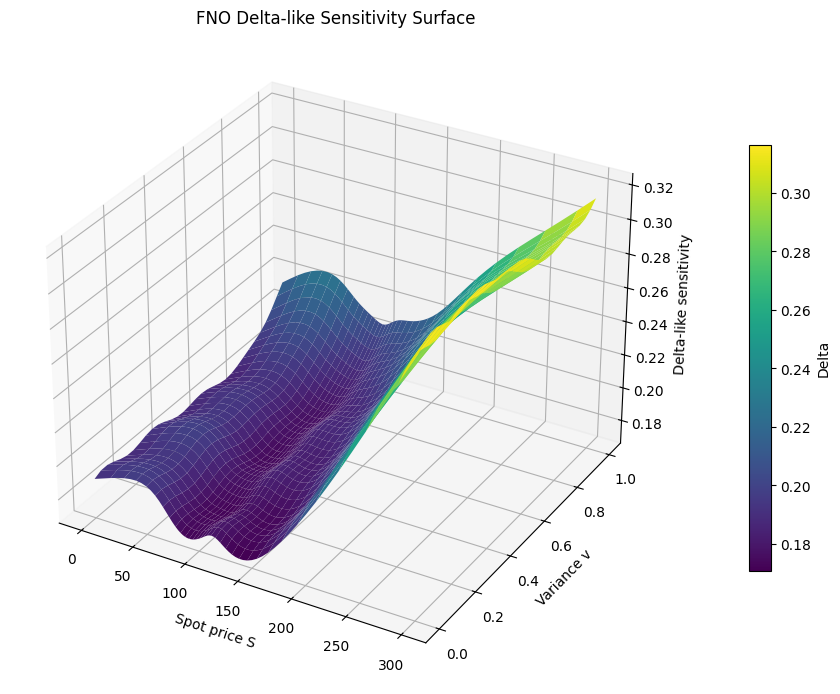

In [31]:
delta_np = delta_surface.squeeze(0).numpy()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_np, V_np, delta_np, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("Spot price S")
ax.set_ylabel("Variance v")
ax.set_zlabel("Delta-like sensitivity")
ax.set_title("FNO Delta-like Sensitivity Surface")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="Delta")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fno_delta_surface_3d.png", dpi=200)
plt.show()

### Vega-like / v0-sensitivity surface

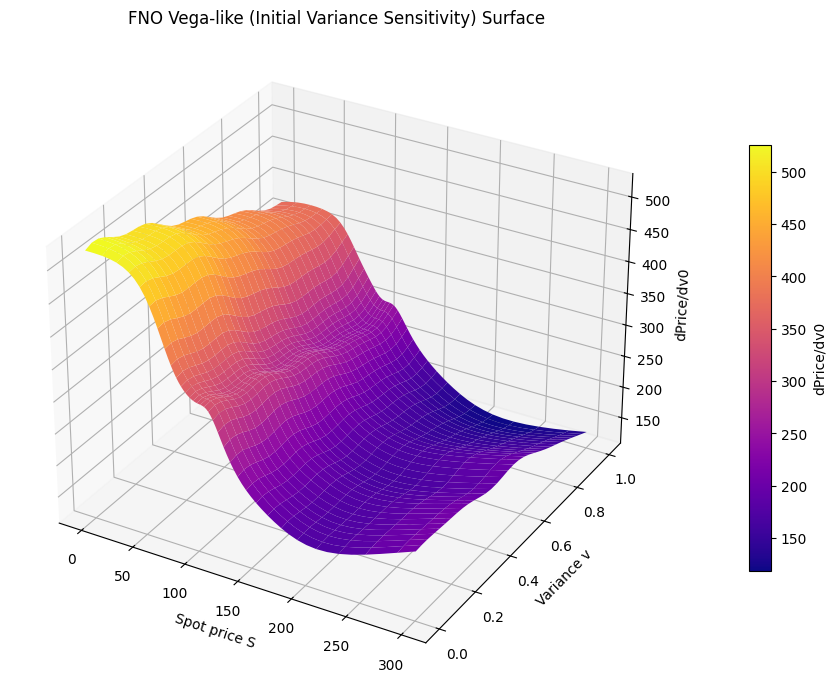

In [32]:
vega_like_np = vega_like_surface.squeeze(0).numpy()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S_np, V_np, vega_like_np, cmap="plasma", linewidth=0, antialiased=True)
ax.set_xlabel("Spot price S")
ax.set_ylabel("Variance v")
ax.set_zlabel("dPrice/dv0")
ax.set_title("FNO Vega-like (Initial Variance Sensitivity) Surface")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label="dPrice/dv0")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fno_vega_like_surface_3d.png", dpi=200)
plt.show()

## 16. FNO inference-time benchmark

This uses the repository's timing helper with warm-up runs and repeated inference.

In [33]:
bench_n = min(FNO_BENCHMARK_BATCH_SIZE, len(test_scaled_dataset))
bench_x = torch.stack([test_scaled_dataset[i][0] for i in range(bench_n)], dim=0)

fno_benchmark_result = benchmark_fno(
    model=model,
    batch=bench_x,
    device=device,
    warmup=FNO_WARMUP,
    repeats=FNO_REPEATS,
)

fno_time = fno_benchmark_result.average_time
fno_throughput = fno_benchmark_result.throughput

fno_results_df = pd.DataFrame([
    {"Metric": "FNO average inference time (s/batch)", "Value": fno_time},
    {"Metric": "FNO throughput (samples/s)", "Value": fno_throughput},
])

display(fno_results_df)
fno_results_df.to_csv(RESULTS_DIR / "fno_benchmark.csv", index=False)

,Metric,Value
0,FNO average inference time (s/batch),0.004413
1,FNO throughput (samples/s),906.335464


## 17. Optional ADI benchmark

This cell is **disabled by default**.

The repository contains an HV-ADI reference solver and timing helper. The benchmark parameters
(`strike`, `rate`, `maturity`, and `n_steps`) should match the reference setup you intend to report.

The ADI helper expects the first five channels to contain the **raw Heston parameters**, so the
benchmark below deliberately uses raw inputs rather than normalized FNO inputs.

Run this only after the FNO results are working.

In [ ]:
if RUN_ADI_BENCHMARK:
    from heston_fno.benchmarking.adi import (
        create_adi_benchmark_fn,
        benchmark_adi,
    )

    # Raw input tensors: first 5 channels are raw Heston parameters.
    raw_batch = torch.stack(
        [full_dataset[int(test_idx[i])][0] for i in range(bench_n)],
        dim=0,
    )

    adi_fn = create_adi_benchmark_fn(
        s_grid=s_grid,
        v_grid=v_grid,
        strike=ADI_STRIKE,
        r=ADI_RATE,
        maturity=ADI_MATURITY,
        n_steps=ADI_N_STEPS,
    )

    adi_result = benchmark_adi(
        adi_fn=adi_fn,
        batch=raw_batch,
        warmup=ADI_WARMUP,
        repeats=ADI_REPEATS,
    )

    adi_time = adi_result.average_time
    adi_throughput = adi_result.throughput

    comparison = pd.DataFrame([
        {"Method": "FNO", "Average time (s/batch)": fno_time, "Throughput (samples/s)": fno_throughput},
        {"Method": "ADI", "Average time (s/batch)": adi_time, "Throughput (samples/s)": adi_throughput},
    ])

    comparison["Speedup vs ADI"] = np.nan
    comparison.loc[comparison["Method"] == "FNO", "Speedup vs ADI"] = adi_time / fno_time

    display(comparison)
    comparison.to_csv(RESULTS_DIR / "fno_vs_adi_benchmark.csv", index= False)

else:
    print("ADI benchmark skipped. Set RUN_ADI_BENCHMARK = True to run it.")

ADI benchmark skipped. Set RUN_ADI_BENCHMARK = True to run it.


In [35]:
# ============================================================
# OPTIONAL — Save checkpoint to Google Drive for future sessions
# ============================================================

SAVE_CHECKPOINT_TO_DRIVE = False

if SAVE_CHECKPOINT_TO_DRIVE:
    drive_destination = Path("/content/drive/MyDrive/heston_fno.pth")
    shutil.copy2(CHECKPOINT_PATH, drive_destination)
    print("Checkpoint saved to:", drive_destination)
else:
    print("Checkpoint not copied to Drive. Set SAVE_CHECKPOINT_TO_DRIVE = True when desired.")

Checkpoint not copied to Drive. Set SAVE_CHECKPOINT_TO_DRIVE = True when desired.


## 18. Save a compact report summary

In [ ]:
report_summary = {
    "device": str(device),
    "checkpoint": str(CHECKPOINT_PATH),
    "test_samples_evaluated": len(test_scaled_dataset),
    "surface_test_position": SURFACE_TEST_POSITION,
    "surface_original_dataset_index": surface_raw_index,
    "RMSE": rmse_value,
    "MAE": mae_value,
    "Maximum Absolute Error": max_abs,
    "Mean Relative Error": mre_value,
    "Relative L2 Error": relative_l2_value,
    "R2": r2_value,
    "FNO average inference time (s/batch)": fno_time,
    "FNO throughput (samples/s)": fno_throughput,
}

summary_df = pd.DataFrame(
    [{"Metric": k, "Value": v} for k, v in report_summary.items()]
)
display(summary_df)

with open(RESULTS_DIR / "results_summary.txt", "w", encoding="utf-8") as f:
    for key, value in report_summary.items():
        f.write(f"{key}: {value}\n")

print("\nAll result files saved under:")
print(RESULTS_DIR)